# Topic 21 Nyquist 

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [125]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

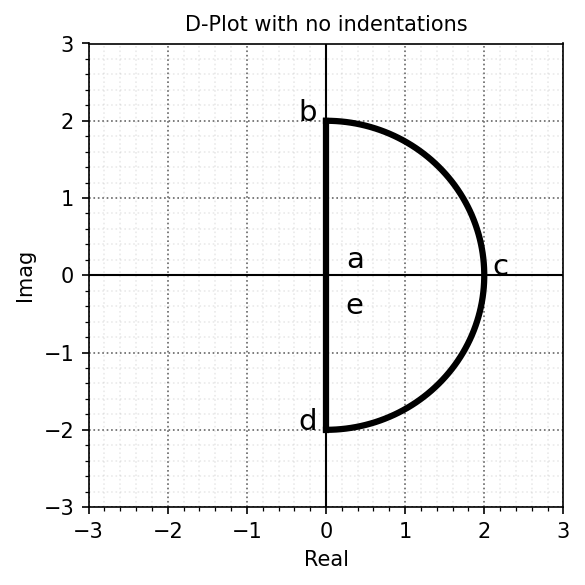

In [126]:
r = 2
an = np.linspace(np.pi/2, -np.pi/2, 100) 
fig, (c3) = plt.subplots(ncols=1, figsize=(4, 4))
c3.plot(r * np.cos(an), r * np.sin(an),'k',lw=3)
c3.plot([0,0],[-r,r],'k',lw=3)
c3.set_xlim((-3,3))
c3.set_ylim((-3,3))
bm.nicegrid(c3)
c3.text(.25,0.1,'a',fontsize=14) 
c3.text(.250,-0.5,'e',fontsize=14) 
c3.text(-.35,-r,'d',fontsize=14) 
c3.text(r+.1,0,'c',fontsize=14) 
c3.text(-.35,r,'b',fontsize=14) 
c3.set_xlabel('Real')
c3.set_ylabel('Imag')
c3.set_title('D-Plot with no indentations')
plt.savefig("./figs/L19_circ2.pdf", dpi=600)
plt.show()

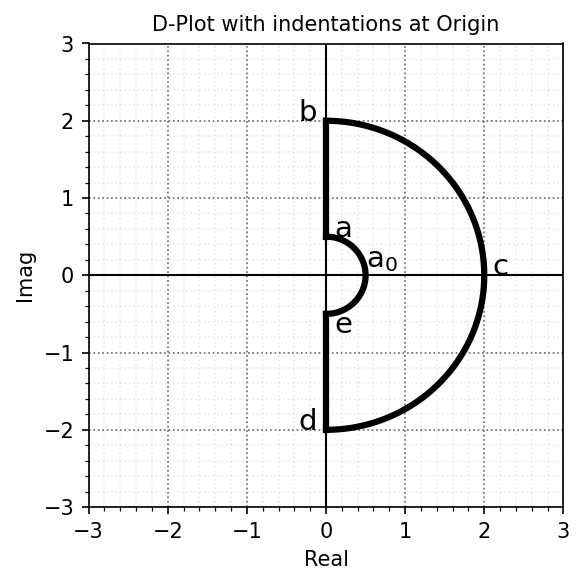

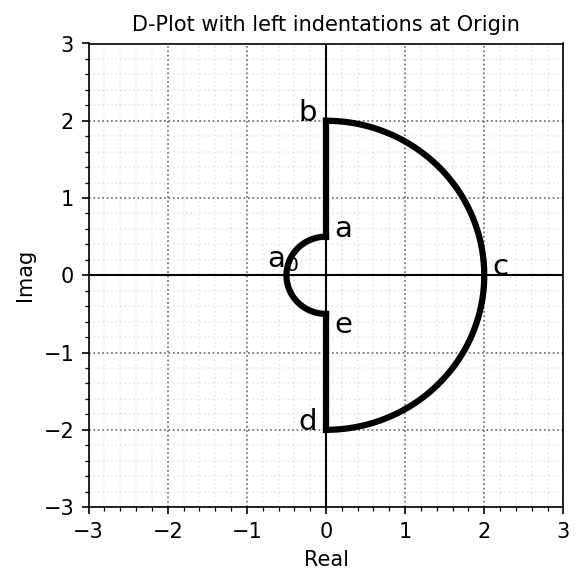

In [127]:
RR = 0.5
r = 2
an = np.linspace(np.pi/2, -np.pi/2, 100) 
fig, (c3) = plt.subplots(ncols=1, figsize=(4, 4))
c3.plot(r * np.cos(an), r * np.sin(an),'k',lw=3)
c3.plot(RR * np.cos(an), RR * np.sin(an),'k',lw=3)
c3.plot([0,0],[-r,-RR],'k',lw=3)
c3.plot([0,0],[RR,r],'k',lw=3)
c3.set_xlim((-3,3))
c3.set_ylim((-3,3))
bm.nicegrid(c3)
c3.text(0.1,RR,'a',fontsize=14) 
c3.text(RR,0.1,r'a$_0$',fontsize=14) 
c3.text(.1,-RR-.25,'e',fontsize=14) 
c3.text(-.35,-r,'d',fontsize=14) 
c3.text(r+.1,0,'c',fontsize=14) 
c3.text(-.35,r,'b',fontsize=14) 
c3.set_xlabel('Real')
c3.set_ylabel('Imag')
c3.set_title('D-Plot with indentations at Origin')
plt.savefig("./figs/L19_circ3.pdf", dpi=600)
plt.show()

fig, (c3) = plt.subplots(ncols=1, figsize=(4, 4))
c3.plot(r * np.cos(an), r * np.sin(an),'k',lw=3)
c3.plot(-RR * np.cos(an), RR * np.sin(an),'k',lw=3)
c3.plot([0,0],[-r,-RR],'k',lw=3)
c3.plot([0,0],[RR,r],'k',lw=3)
c3.set_xlim((-3,3))
c3.set_ylim((-3,3))
bm.nicegrid(c3)
c3.text(0.1,RR,'a',fontsize=14) 
c3.text(-RR-.25,0.1,r'a$_0$',fontsize=14) 
c3.text(.1,-RR-.25,'e',fontsize=14) 
c3.text(-.35,-r,'d',fontsize=14) 
c3.text(r+.1,0,'c',fontsize=14) 
c3.text(-.35,r,'b',fontsize=14) 
c3.set_xlabel('Real')
c3.set_ylabel('Imag')
c3.set_title('D-Plot with left indentations at Origin')
plt.savefig("./figs/L19_circ4.pdf", dpi=600)
plt.show()

## Impact of the Relative Degree

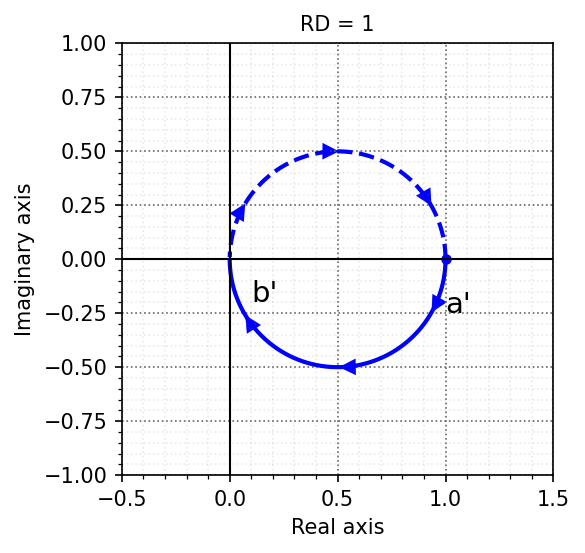

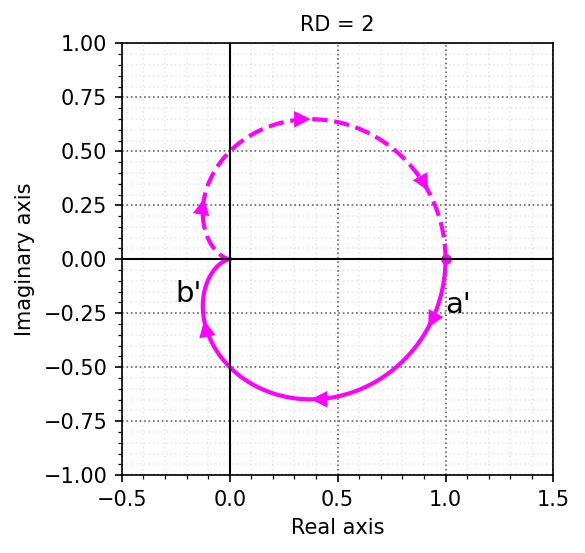

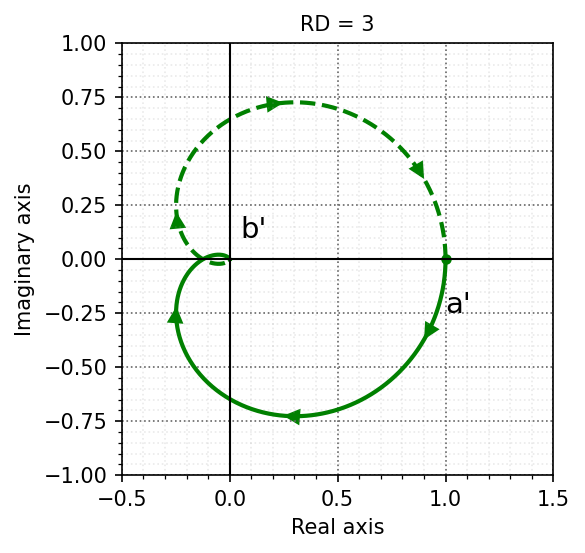

In [128]:
#21-3
# 3 poles
p1 = 1
p2 = 0.9
p3 = 0.8

# 3 systems
G1 = ct.tf([p1],[1, p1])
G2 = G1*ct.tf([p2],[1, p2])
G3 = G2*ct.tf([p3],[1, p3])

RR = 0.05

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(G1,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,color='b',linewidth=2,ax=ax)
ax.set_xlim([-.5,1.5])
ax.set_ylim([-1.,1.])
ax.set_aspect('equal')
ax.text(1,-0.25,"a'",fontsize=14) 
ax.text(.1,-.2,"b'",fontsize=14) 
ax.set_title('RD = 1')
bm.nicegrid(ax)
plt.savefig("./figs/L19_3a.pdf", dpi=600)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
#ct.nyquist_plot(G2,w,indent_direction='right',indent_radius=RR,indent_points=100,**kwargs)
resp = ct.nyquist_response(G2,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,color='magenta',linewidth=2,ax=ax)
ax.set_xlim([-.5,1.5])
ax.set_ylim([-1.,1.])
ax.set_aspect('equal')
ax.text(1,-0.25,"a'",fontsize=14) 
ax.text(-.25,-.2,"b'",fontsize=14) 
ax.set_title('RD = 2')
bm.nicegrid(ax)
plt.savefig("./figs/L19_3b.pdf", dpi=600)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
#ct.nyquist_plot(G3,w,indent_direction='right',indent_radius=RR,indent_points=100,**kwargs)
resp = ct.nyquist_response(G3,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,color='g',linewidth=2,ax=ax)
ax.set_xlim([-.5,1.5])
ax.set_ylim([-1.,1.])
ax.set_aspect('equal')
ax.text(1,-0.25,"a'",fontsize=14) 
ax.text(.05,.1,"b'",fontsize=14) 
ax.set_title('RD = 3')
bm.nicegrid(ax)
plt.savefig("./figs/L19_3c.pdf", dpi=600)


## Indent Left instead of Right

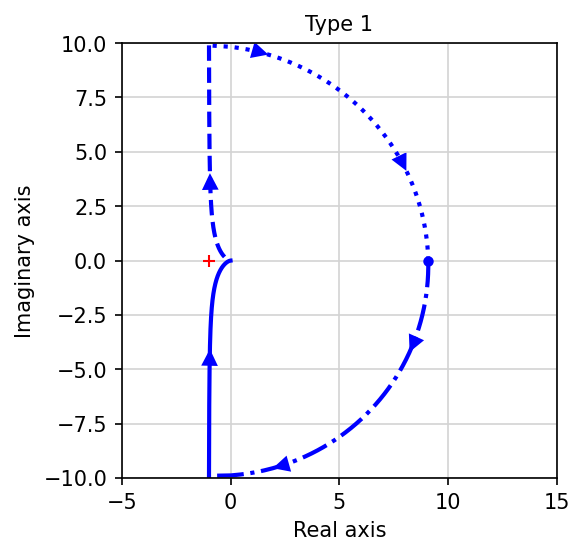

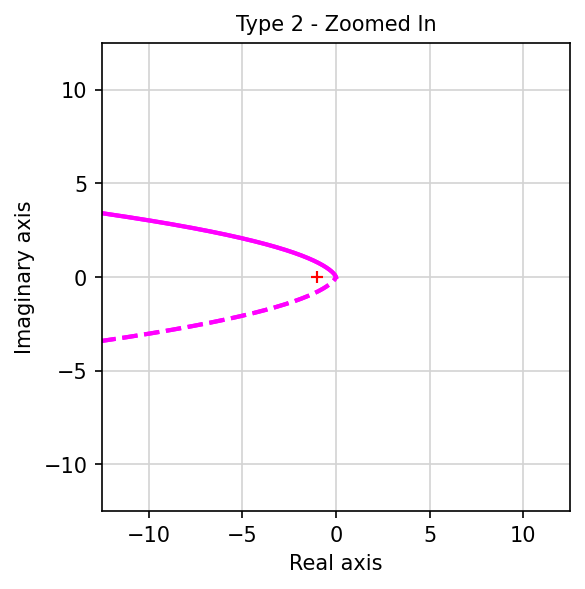

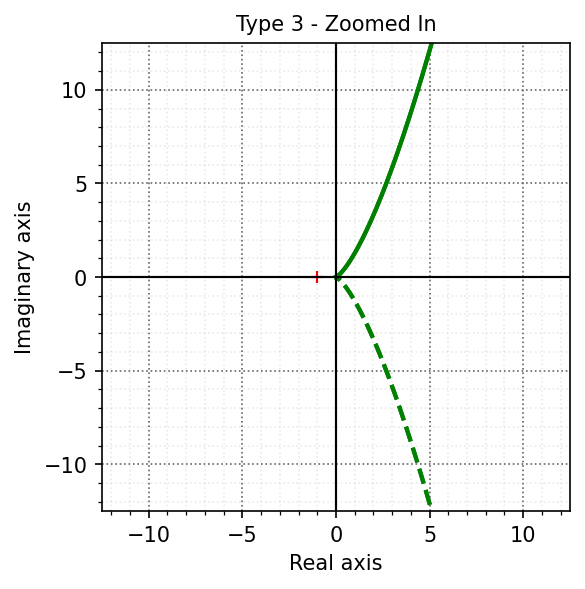

In [129]:
#21-5
G1 = ct.tf([1],[1, 1]) * ct.tf([1],[1, 0])
G2 = ct.tf([1],[1, 1]) * ct.tf([1],[1, 0])**2
G3 = ct.tf([1],[1, 1]) * ct.tf([1],[1, 0])**3

w=np.logspace(-6,6,5000)
fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
RR = 0.1
resp = ct.nyquist_response(G1,w,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,color='b',linewidth=2,ax=ax)
plt.xlim([-5,15])
plt.ylim([-10,10])
ax.set_aspect('equal')
ax.set_title('Type 1')
plt.savefig("./figs/L19_Nyq_type1.pdf", dpi=600)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
RR = 0.01
resp = ct.nyquist_response(G2,w,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,color='magenta',linewidth=2,ax=ax)
plt.xlim(np.array(5)*[-25,25])
plt.ylim(np.array(5)*[-25,25])
ax.set_aspect('equal')
ax.set_title('Type 2')
plt.savefig("./figs/L19_Nyq_type2.pdf", dpi=600)

# zoomed in
ct.nyquist_plot(resp,color='magenta',linewidth=2,ax=ax)
plt.xlim(np.array(.5)*[-25,25])
plt.ylim(np.array(.5)*[-25,25])
ax.set_aspect('equal')
ax.set_title('Type 2 - Zoomed In')
plt.savefig("./figs/L19_Nyq_type2z.pdf", dpi=600)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
#ct.nyquist_plot(G3,w,indent_direction='right',indent_radius=RR,indent_points=100,**kwargs)
resp = ct.nyquist_response(G3,w,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,color='g',linewidth=2,ax=ax)
plt.xlim(np.array(5)*[-25,25])
plt.ylim(np.array(5)*[-25,25])
ax.set_aspect('equal')
ax.set_title('Type 3')
bm.nicegrid(ax)
plt.savefig("./figs/L19_Nyq_type3.pdf", dpi=600)

ct.nyquist_plot(resp,color='g',linewidth=2,ax=ax)
plt.xlim(np.array(.5)*[-25,25])
plt.ylim(np.array(.5)*[-25,25])
ax.set_aspect('equal')
ax.set_title('Type 3 - Zoomed In')
bm.nicegrid(ax)
plt.savefig("./figs/L19_Nyq_type3z.pdf", dpi=600)


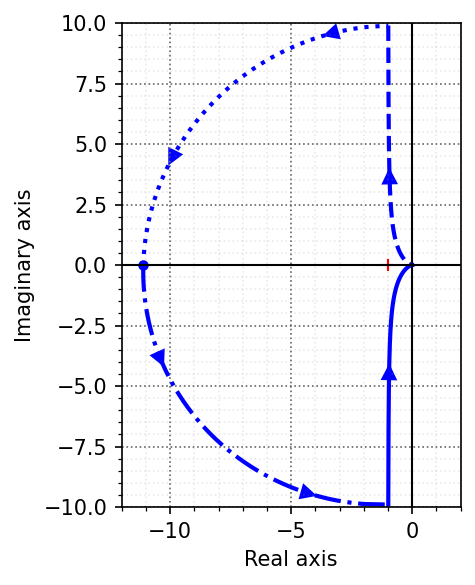

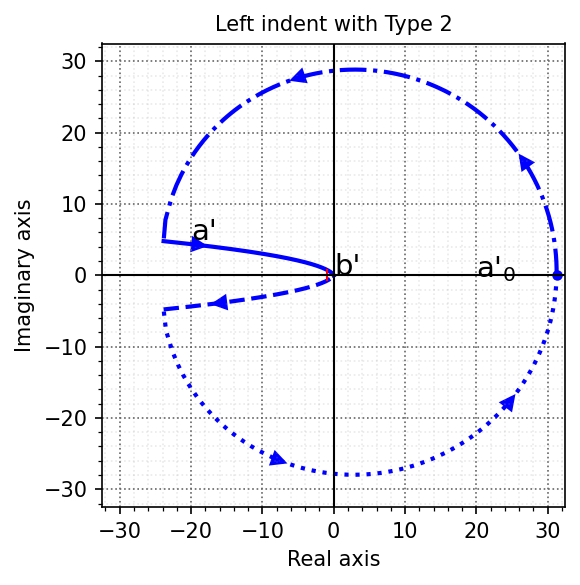

In [130]:
w=np.logspace(-6,6,5000)
fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
RR = 0.1
resp = ct.nyquist_response(G1,w,indent_direction='left',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,color='b',linewidth=2,ax=ax)
plt.xlim([-12,2])
plt.ylim([-10,10])
ax.set_aspect('equal')
bm.nicegrid(ax,.25)
plt.savefig("./figs/L19_Nyq_type1_left.pdf", dpi=600)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(G2,w,indent_direction='left',indent_radius=.2,indent_points=100)
ct.nyquist_plot(resp,color='b',linewidth=2,ax=ax)
plt.xlim(np.array(1.3)*[-25,25])
plt.ylim(np.array(1.3)*[-25,25])
ax.set_aspect('equal')
ax.set_title('Left indent with Type 2')
bm.nicegrid(ax,.1)
ax.text(20,-0.25,"a'$_0$",fontsize=14) 
ax.text(-20,5,"a'",fontsize=14) 
ax.text(.05,.1,"b'",fontsize=14) 
plt.savefig("./figs/L19_Nyq_type2_left.pdf", dpi=600)


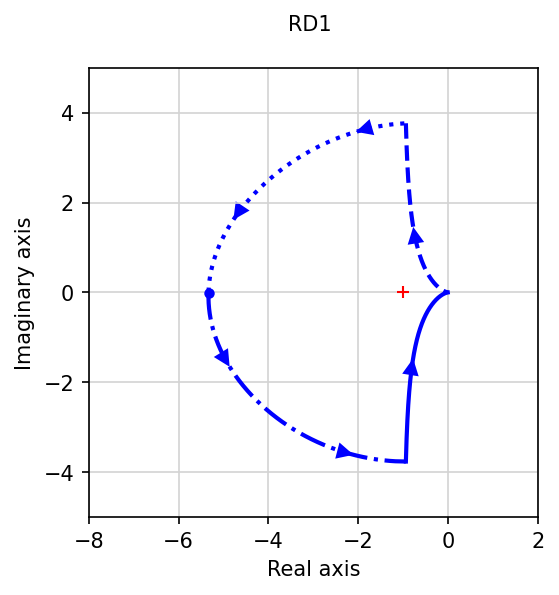

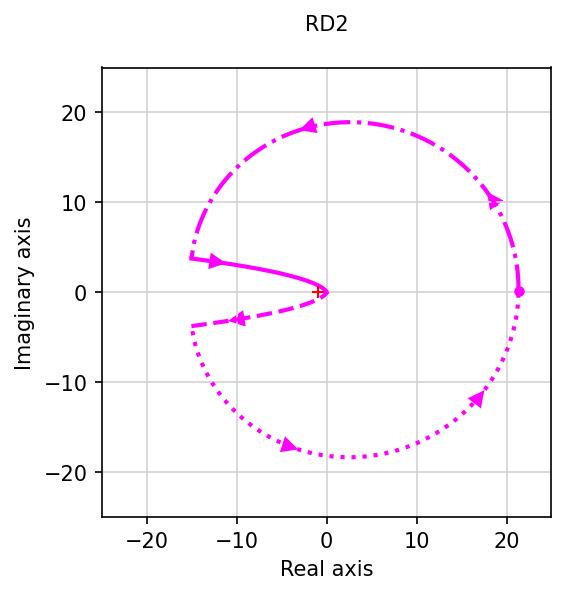

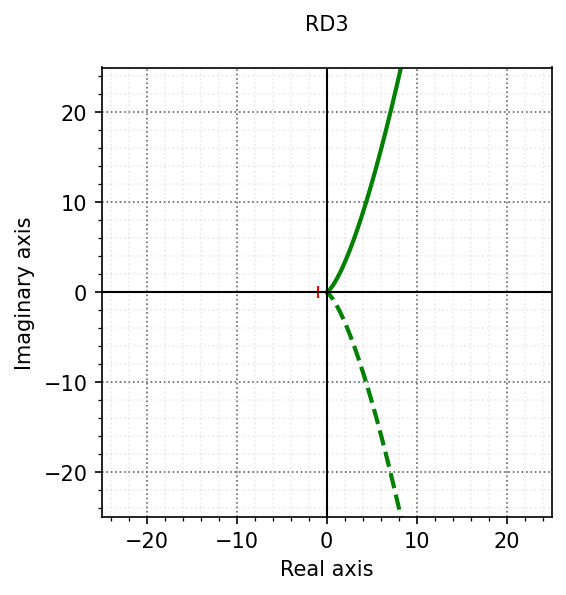

In [131]:
# Indent left
#20-8
RR = .25
w=np.logspace(-3,1,5000)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
kwargs = {'color':'b','linewidth':2}
resp = ct.nyquist_response(G1,w,indent_direction='left',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,title='RD1 ',**kwargs)
plt.xlim([-8,2])
plt.ylim([-5,5])
ax.set_aspect('equal')

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
kwargs = {'color':'magenta','linewidth':2}
resp = ct.nyquist_response(G2,w,indent_direction='left',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,title='RD2')
plt.xlim([-25,25])
plt.ylim([-25,25])
ax.set_aspect('equal')

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
kwargs = {'color':'g','linewidth':2}
resp = ct.nyquist_response(G3,w,indent_direction='left',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,title='RD3')
plt.xlim([-25,25])
plt.ylim([-25,25])
ax.set_aspect('equal')
bm.nicegrid(ax,-1)


Found break-in/out at K =  3.732
At possible locations s = -1.366

Found break-in/out at K =  0.268
At possible locations s =  0.366


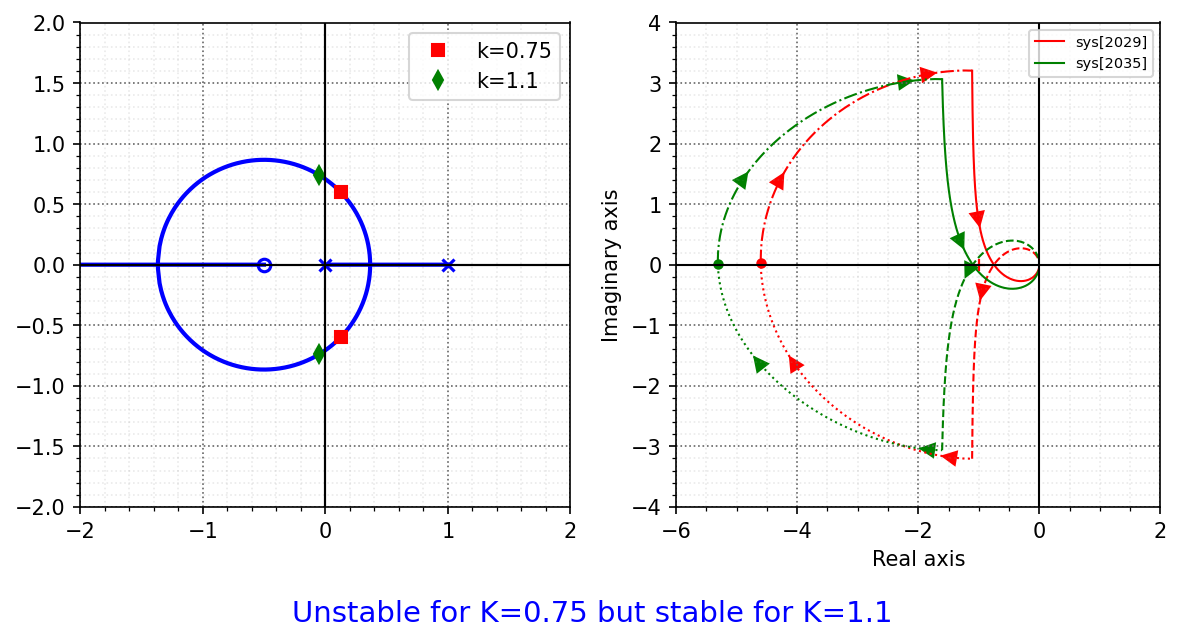

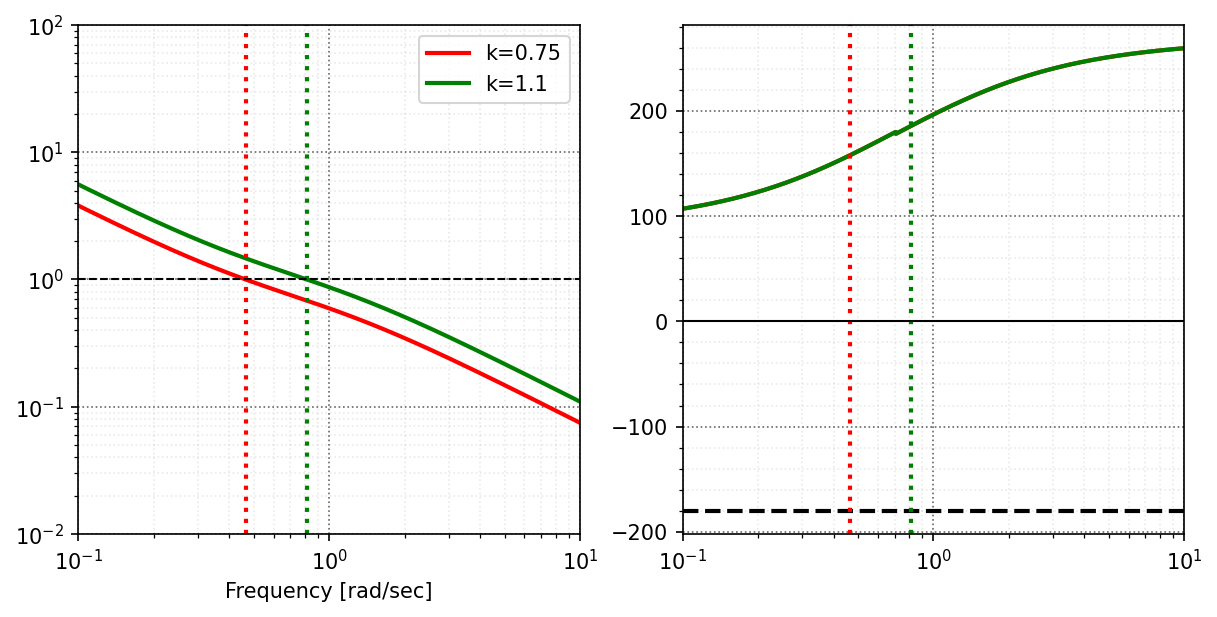

In [132]:
# stability analysis example on 21-10
gain1 = 0.75
gain2 = 1.1
G = 0.5*ct.tf((2,1),(1,-1,0))
Gcl1 = ct.feedback(G,gain1)
Gcl3 = ct.feedback(G,gain2)
scl1 = Gcl1.poles()
scl3 = Gcl3.poles()

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150)
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b', ax=ax[0])
ax[0].set_xlim([-2, 2]);ax[0].set_ylim([-2, 2])
bm.nicegrid(ax[0])
#ax[0].set_title('Gamma > 0, K={:2d}'.format(K),loc='left')
ax[0].plot(scl1.real,scl1.imag,'rs',ms=6,label='k='+str(gain1))
ax[0].plot(scl3.real,scl3.imag,'gd',ms=6,label='k='+str(gain2))
h, l = ax[0].get_legend_handles_labels()
ax[0].legend(handles=[item for item in h[2:]], labels= [item for item in l[2:]])
                                                    
RR = .15
plt.sca(ax[1])
kwargs = {'color':'r','linewidth':1}
resp = ct.nyquist_response(gain1*G,w,indent_direction='right',indent_radius=gain1*RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,ax=ax[1])
kwargs = {'color':'g','linewidth':1}
resp = ct.nyquist_response(gain2*G,w,indent_direction='right',indent_radius=gain2*RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,ax=ax[1])
plt.xlim([-6,2])
plt.ylim([-4,4])
ax[1].set_aspect('equal')
bm.nicegrid(ax)
cm.caption("Unstable for K="+str(gain1)+" but stable for K="+str(gain2),fig)
plt.savefig('./figs/L15_10.pdf')
plt.show()

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
j = complex(0,1)
Gfreq1 = G(j*w)

ax[0].loglog(w,gain1*np.abs(Gfreq1),'r')
ax[1].semilogx(w,np.unwrap(np.angle(Gfreq1)*cm.r2d),'r')
ax[0].loglog(w,gain2*np.abs(Gfreq1),'g')
ax[1].semilogx(w,np.unwrap(np.angle(Gfreq1)*cm.r2d),'g')

ax1,ax2 = plt.gcf().axes
ax1.legend(('k='+str(gain1),'k='+str(gain2)))
ax2.axhline(y=-180,c='k',ls="--")
wc1 = cm.find_wc(w,gain1*G)
wc3 = cm.find_wc(w,gain2*G)
for wwc in wc1[::2]:
    ax1.axvline(x=wwc,c='r',ls=":")
    ax2.axvline(x=wwc,c='r',ls=":")
for wwc in wc3[::2]:
    ax1.axvline(x=wwc,c='g',ls=":")
    ax2.axvline(x=wwc,c='g',ls=":")
ax[0].set_xlim([.1,10])
ax[1].set_xlim([.1,10])
ax[0].set_ylim([.01,100])
ax[0].set_xlabel("Frequency [rad/sec]")
bm.nicegrid(ax)
plt.savefig('./figs/L15_11.pdf')
plt.show()

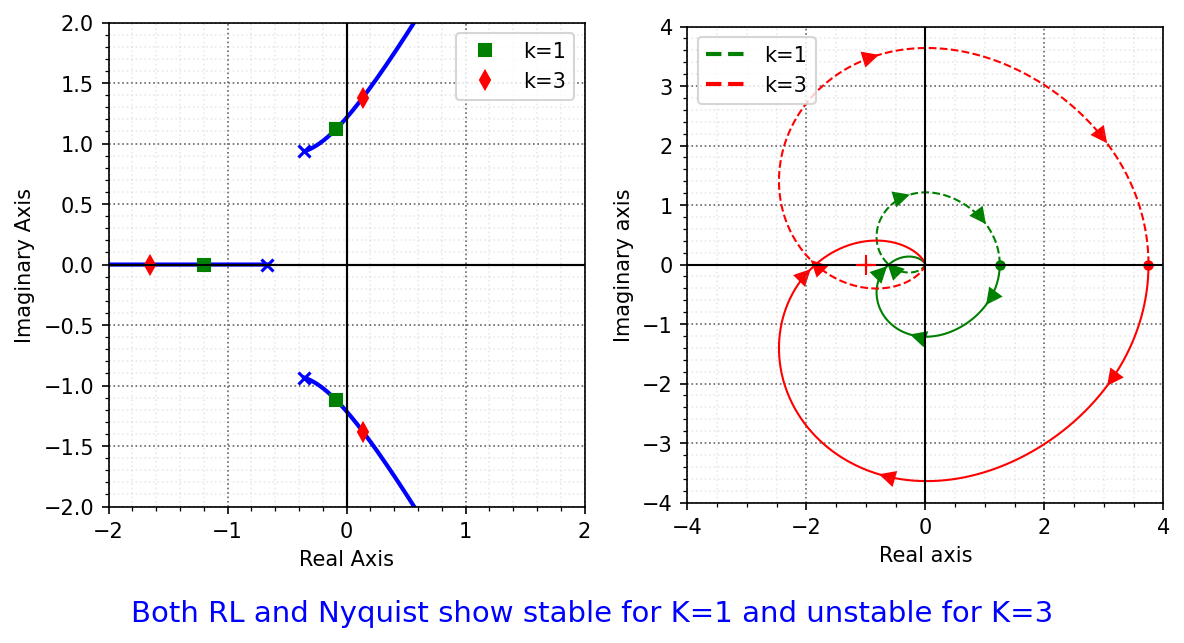

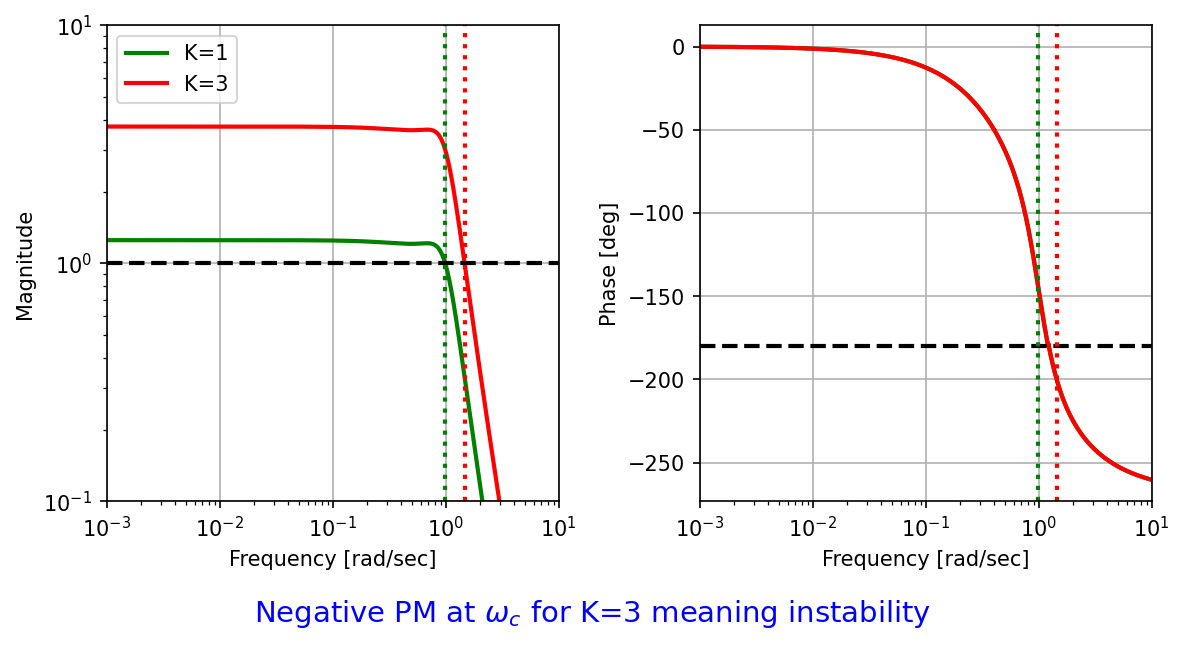

In [133]:
# stability analysis example on 21-9
RR = .15

G = ct.tf(1.25, (1.5,2.061,2.207,1))
Gcl1 = ct.feedback(G,1)
Gcl3 = ct.feedback(3*G,1)

scl1 = Gcl1.poles()
scl3 = Gcl3.poles()

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150)
rl =  ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b', ax=ax[0])
ax[0].set_xlim([-2, 2]);ax[0].set_ylim([-2, 2])
bm.nicegrid(ax[0])
#ax[0].set_title('Gamma > 0, K={:2d}'.format(K),loc='left')
ax[0].plot(scl1.real,scl1.imag,'gs',ms=6,label='k=1')
ax[0].plot(scl3.real,scl3.imag,'rd',ms=6,label='k=3')
# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='green', marker='s', linestyle='None'),
    Line2D([0], [0], color='red', marker='d', linestyle='None')
]
ax[0].legend(custom_lines, ['k='+str(1), 'k='+str(3)])
ax[0].set_xlabel("Real Axis")
ax[0].set_ylabel("Imaginary Axis")

plt.sca(ax[1])
kwargs = {'color':'g','linewidth':1}
resp = ct.nyquist_response(G,w,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,ax=ax[1])
kwargs = {'color':'r','linewidth':1}
resp = ct.nyquist_response(3*G,w,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,ax=ax[1])
plt.xlim([-4,4])
plt.ylim([-4,4])
ax[1].set_aspect('equal')
bm.nicegrid(ax)
plt.plot(-1,0,'r+',ms=10,zorder=100)
cm.caption("Both RL and Nyquist show stable for K=1 and unstable for K=3",fig)
plt.savefig('./figs/L19_9a.pdf')
# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='green', linestyle='--'),
    Line2D([0], [0], color='red', linestyle='--')
]
ax[1].legend(custom_lines, ['k='+str(1), 'k='+str(3)])
plt.show()

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150)
Gfreq1 = G(j*w)
Gfreq3 = (3*G)(j*w)
    
ax[0].loglog(w,np.abs(Gfreq1),'g')
ax[1].semilogx(w,np.unwrap(np.angle(Gfreq1)*cm.r2d),'g')
ax[0].loglog(w,np.abs(Gfreq3),'r')
ax[1].semilogx(w,np.unwrap(np.angle(Gfreq3)*cm.r2d),'r')    

ax1,ax2 = plt.gcf().axes
ax1.legend(('K=1','K=3'))
ax2.axhline(y=-180,c='k',ls="--")
ax1.axhline(y=1,c='k',ls="--")
ax1.set_ylim(.1,10)
wc1,idx1 = cm.find_wc(w,G)
wc3,idx3 = cm.find_wc(w,3*G)
ax1.axvline(x=wc1,c='g',ls=":")
ax2.axvline(x=wc1,c='g',ls=":")
ax1.axvline(x=wc3,c='r',ls=":")
ax2.axvline(x=wc3,c='r',ls=":")
ax1.set_xlabel("Frequency [rad/sec]")
ax2.set_xlabel("Frequency [rad/sec]")
ax1.set_ylabel("Magnitude")
ax2.set_ylabel("Phase [deg]")
cm.caption(r"Negative PM at $\omega_c$ for K=3 meaning instability",fig)
plt.savefig('./figs/L19_9b.pdf')


Poles of OL system:  [ 2. +0.j -0.3+0.j]

Found break-in/out at K =  2.057
At possible locations s = -1.207

Found break-in/out at K =  0.643
At possible locations s =  0.207


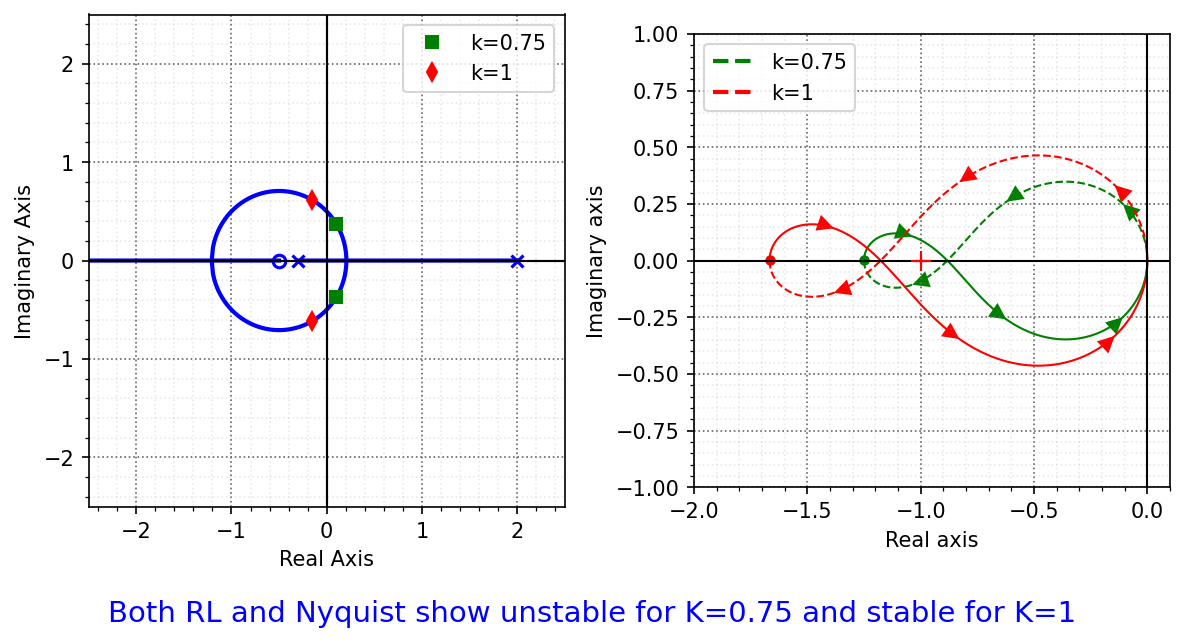

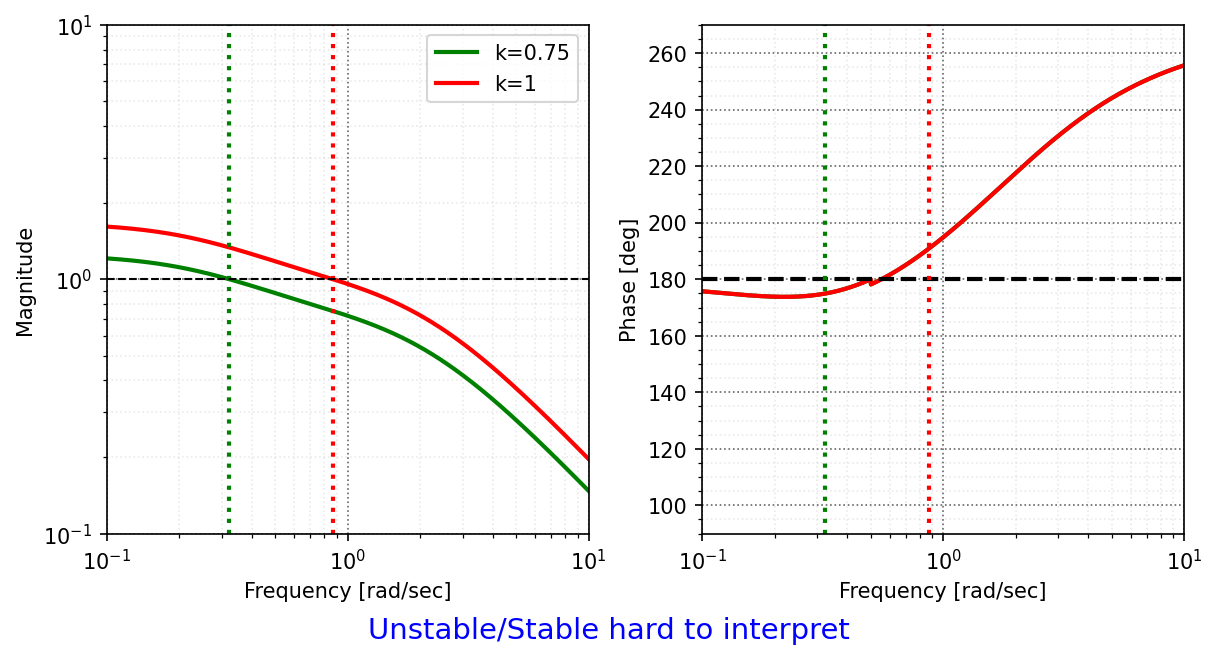

In [134]:
# stability analysis example on 21-10
gain1 = 0.75
gain2 = 1

G = ct.tf((2,1), (1,-1.7,-0.6))
print("Poles of OL system: ",G.poles())
Gcl1 = ct.feedback(gain1*G,1)
Gcl2 = ct.feedback(gain2*G,1)

scl1 = Gcl1.poles()
scl2 = Gcl2.poles()

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150)
rl =  ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b', ax=ax[0])
ax[0].set_xlim([-2.5, 2.5]);ax[0].set_ylim([-2.5, 2.5])
bm.nicegrid(ax[0])
#ax[0].set_title('Gamma > 0, K={:2d}'.format(K),loc='left')
ax[0].plot(scl1.real,scl1.imag,'gs',ms=6,label='k='+str(gain1))
ax[0].plot(scl2.real,scl2.imag,'rd',ms=6,label='k='+str(gain2))
# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='green', marker='s', linestyle='None'),
    Line2D([0], [0], color='red', marker='d', linestyle='None')
]
ax[0].legend(custom_lines, ['k='+str(gain1), 'k='+str(gain2)])
ax[0].set_xlabel("Real Axis")
ax[0].set_ylabel("Imaginary Axis")

plt.sca(ax[1])
ww = np.sort(np.append(w*1e3,w,0))
kwargs = {'color':'g','linewidth':1}
resp = ct.nyquist_response(gain1*G,ww,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,ax=ax[1])
kwargs = {'color':'r','linewidth':1}
resp = ct.nyquist_response(gain2*G,ww,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,ax=ax[1])
plt.xlim([-2,.1])
plt.ylim([-1,1])
ax[1].set_aspect('equal')
plt.plot(-1,0,'r+',ms=10,zorder=100)
bm.nicegrid(ax)
# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='green', linestyle='--'),
    Line2D([0], [0], color='red', linestyle='--')
]
ax[1].legend(custom_lines, ['k='+str(gain1), 'k='+str(gain2)])
cm.caption("Both RL and Nyquist show unstable for K="+str(gain1)+" and stable for K="+str(gain2),fig)
plt.savefig('./figs/L19_10a.pdf')
plt.show()

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
j = complex(0,1)
Gfreq1 = G(j*w)

ax[0].loglog(w,gain1*np.abs(Gfreq1),'g')
ax[1].semilogx(w,np.unwrap(np.angle(Gfreq1)*cm.r2d),'g')
ax[0].loglog(w,gain2*np.abs(Gfreq1),'r')
ax[1].semilogx(w,np.unwrap(np.angle(Gfreq1)*cm.r2d),'r')

ax1,ax2 = plt.gcf().axes
ax1.legend(('k='+str(gain1),'k='+str(gain2)))
ax2.axhline(y=-180,c='k',ls="--")
ax2.axhline(y=180,c='k',ls="--")
wc1 = cm.find_wc(w,gain1*G)
wc3 = cm.find_wc(w,gain2*G)
for wwc in wc1[::2]:
    ax1.axvline(x=wwc,c='g',ls=":")
    ax2.axvline(x=wwc,c='g',ls=":")
for wwc in wc3[::2]:
    ax1.axvline(x=wwc,c='r',ls=":")
    ax2.axvline(x=wwc,c='r',ls=":")
ax1.set_xlim([.1,10])
ax2.set_xlim([.1,10])
ax1.set_ylim([.1,10])
ax2.set_ylim([90,270])
ax1.set_xlabel("Frequency [rad/sec]")
ax2.set_xlabel("Frequency [rad/sec]")
ax1.set_ylabel("Magnitude")
ax2.set_ylabel("Phase [deg]")
cm.caption("Unstable/Stable hard to interpret",fig)
bm.nicegrid(ax)
plt.savefig('./figs/L19_10b.pdf')
plt.show()


Poles of OL system:  (-0.90 + 0.44i), (-0.90 - 0.44i), 0.000


Found break-in/out at K =  0.159
At possible locations s = -0.763

Found break-in/out at K =  0.177
At possible locations s = -0.437


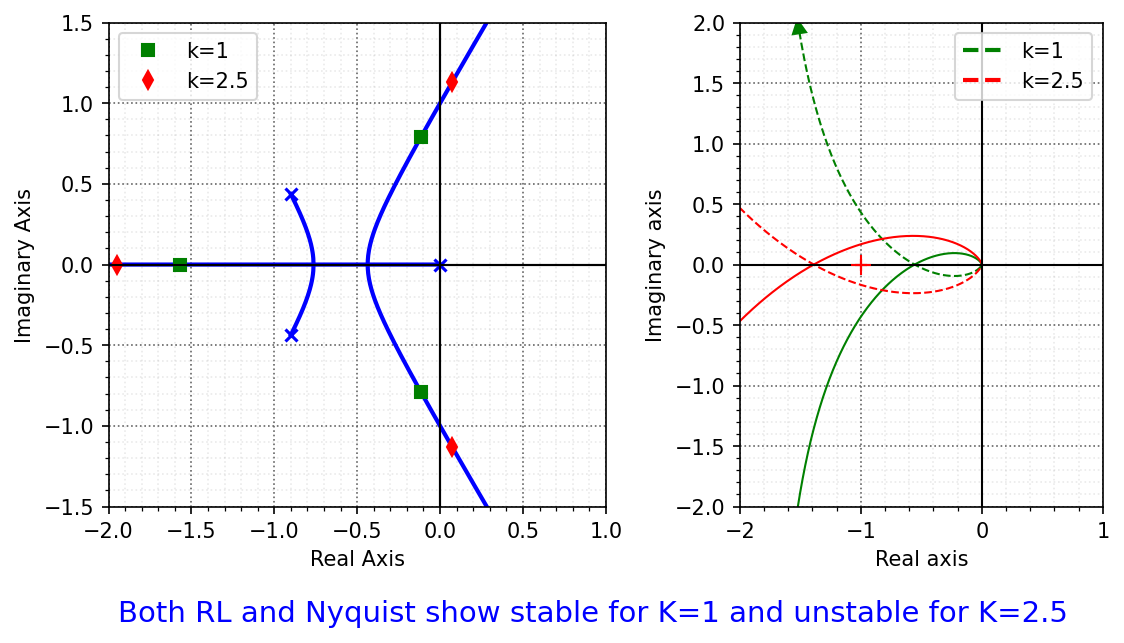

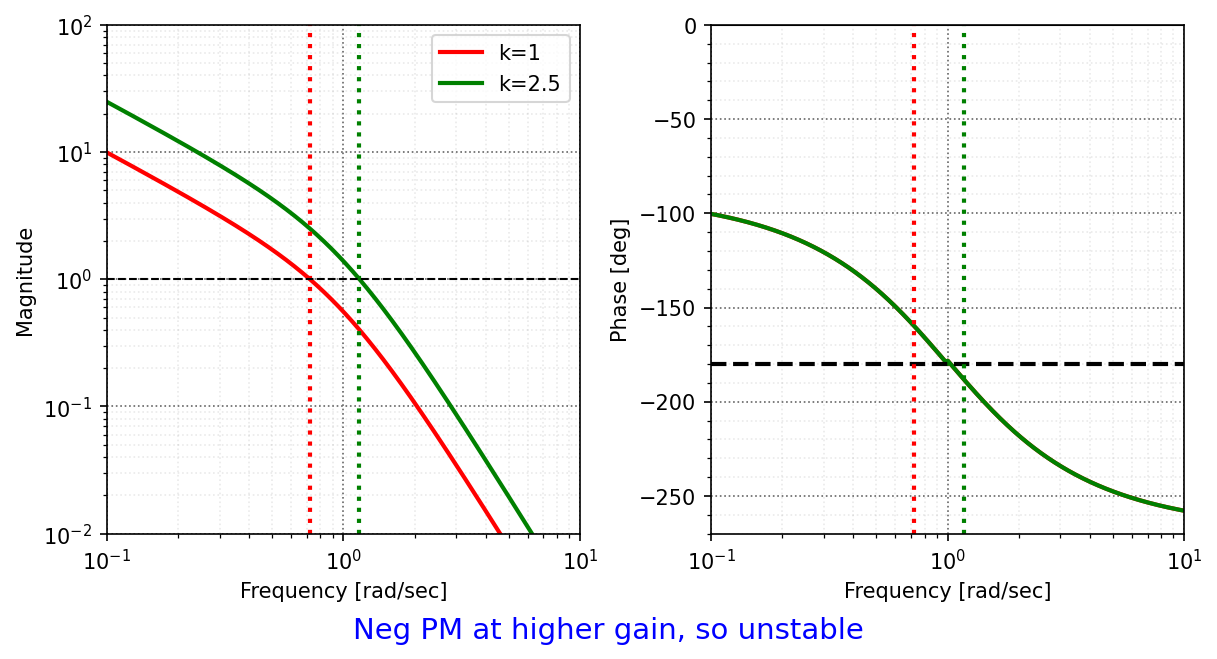

In [135]:
# stability analysis example on 21-11
gain1 = 1
gain2 = 2.5

G = ct.tf(1, (1,1.8,1,0))
cm.pretty_row_print(G.poles(),"Poles of OL system: ")
Gcl1 = ct.feedback(gain1*G,1)
Gcl2 = ct.feedback(gain2*G,1)

scl1 = Gcl1.poles()
scl2 = Gcl2.poles()

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150)
rl =  ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b', ax=ax[0])
ax[0].set_xlim([-2, 1]);ax[0].set_ylim([-1.5, 1.5])
bm.nicegrid(ax[0])
#ax[0].set_title('Gamma > 0, K={:2d}'.format(K),loc='left')
ax[0].plot(scl1.real,scl1.imag,'gs',ms=6,label='k='+str(gain1))
ax[0].plot(scl2.real,scl2.imag,'rd',ms=6,label='k='+str(gain2))
ax[0].set_xlabel("Real Axis")
ax[0].set_ylabel("Imaginary Axis")
# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='green', marker='s', linestyle='None'),
    Line2D([0], [0], color='red', marker='d', linestyle='None')
]
ax[0].legend(custom_lines, ['k='+str(gain1), 'k='+str(gain2)])

plt.sca(ax[1])
kwargs = {'color':'g','linewidth':1}
resp = ct.nyquist_response(gain1*G,w,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,ax=ax[1])
kwargs = {'color':'r','linewidth':1}
resp = ct.nyquist_response(gain2*G,w,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,ax=ax[1])
plt.xlim([-2,1])
plt.ylim([-2,2])
ax[1].set_aspect('equal')
plt.plot(-1,0,'r+',ms=10,zorder=100)
bm.nicegrid(ax)
# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='green', linestyle='--'),
    Line2D([0], [0], color='red', linestyle='--')
]
ax[1].legend(custom_lines, ['k='+str(gain1), 'k='+str(gain2)])
cm.caption("Both RL and Nyquist show stable for K="+str(gain1)+" and unstable for K="+str(gain2),fig)
plt.savefig('./figs/L19_11a.pdf')
plt.show()

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
j = complex(0,1)
Gfreq1 = gain1*G(j*w)
Gfreq3 = gain2*G(j*w)

ax[0].loglog(w,np.abs(Gfreq1),'r')
ax[1].semilogx(w,np.unwrap(np.angle(Gfreq1)*cm.r2d),'r')
ax[0].loglog(w,np.abs(Gfreq3),'g')
ax[1].semilogx(w,np.unwrap(np.angle(Gfreq3)*cm.r2d),'g')

ax1,ax2 = plt.gcf().axes
ax1.legend(('k='+str(gain1),'k='+str(gain2)))
ax2.axhline(y=-180,c='k',ls="--")
wc1 = cm.find_wc(w,gain1*G)
wc3 = cm.find_wc(w,gain2*G)
for wwc in wc1[::2]:
    ax1.axvline(x=wwc,c='r',ls=":")
    ax2.axvline(x=wwc,c='r',ls=":")
for wwc in wc3[::2]:
    ax1.axvline(x=wwc,c='g',ls=":")
    ax2.axvline(x=wwc,c='g',ls=":")
ax1.set_xlim([.1,10])
ax2.set_xlim([.1,10])
ax1.set_ylim([.01,100])
ax2.set_ylim([-270,0])
ax1.set_xlabel("Frequency [rad/sec]")
ax2.set_xlabel("Frequency [rad/sec]")
ax1.set_ylabel("Magnitude")
ax2.set_ylabel("Phase [deg]")
bm.nicegrid(ax)
cm.caption("Neg PM at higher gain, so unstable",fig)
plt.savefig('./figs/L19_11b.pdf')


## Examples on 16-9 and 16-10

<IPython.core.display.Math object>

None

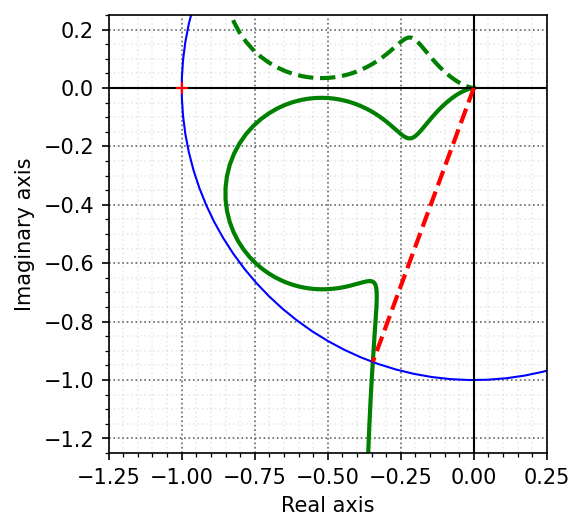

Phase Margin = 69.77


In [136]:
from control_materials import *
# L15 PM/GM Examples
w = np.hstack((0,np.logspace(-3,3,5000)))
an = np.linspace(0, 2 * np.pi, 100) # unit circle

#L(s) =  \frac{0.38( s^2 + 0.1 s + 0.55)}{s(s+1)(s^2+0.06s+0.5)}
G = 0.38*ct.tf([1],[1, 1, 0])*ct.tf([1,.1,.55],[1,.06,.5]) 
display(cm.show_tf_latex(G,'G'))

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(G,w,indent_direction='right',indent_points=100)
ct.nyquist_plot(resp,color='g',linewidth=2,ax=ax)

plt.plot(np.cos(an), np.sin(an),'b-',lw=1)
plt.plot(-1,0,'r+',ms=6,zorder=20)
ax.set_aspect('equal')
plt.xlim([-1.25,.25])
plt.ylim([-1.25,.25])
bm.nicegrid(ax)

gm, pm, wcg, wcp =  ct.margin(G)
#print([gm,wcg,pm,wcp])
plt.plot([0,-np.cos(pm/r2d)],[0,-np.sin(pm/r2d)],'r--')
plt.savefig("./figs/L19_GM_PM_1.pdf", dpi=600)
plt.show()

print("Phase Margin = {:3.2f}".format(pm))


# L21 PM/GM Examples - Robustness Question


<IPython.core.display.Math object>

None

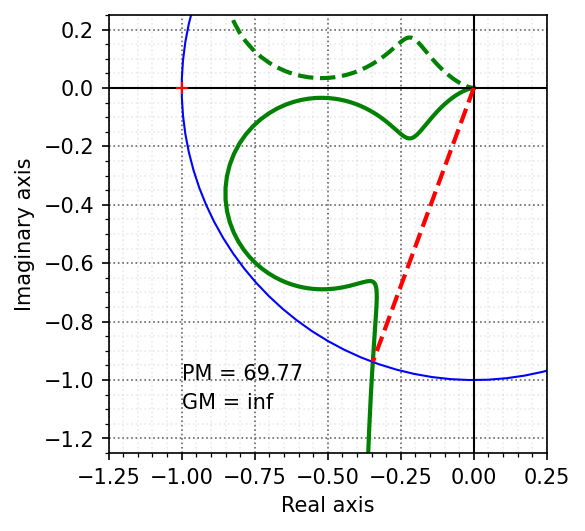

In [137]:
w = np.hstack((0,np.logspace(-3,3,5000)))
an = np.linspace(0, 2 * np.pi, 100) # unit circle

#L(s) =  \frac{0.38( s^2 + 0.1 s + 0.55)}{s(s+1)(s^2+0.06s+0.5)}
G = 0.38*ct.tf([1],[1, 1, 0])*ct.tf([1,.1,.55],[1,.06,.5]) 
display(cm.show_tf_latex(G,'G'))

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(G,w,indent_direction='right',indent_points=100)
ct.nyquist_plot(resp,color='g',linewidth=2,ax=ax)

plt.plot(np.cos(an), np.sin(an),'b-',lw=1)
plt.plot(-1,0,'r+',ms=6,zorder=20)
ax.set_aspect('equal')
plt.xlim([-1.25,.25])
plt.ylim([-1.25,.25])
bm.nicegrid(ax)

gm, pm, wcg, wcp =  ct.margin(G)
plt.plot([0,-np.cos(pm/r2d)],[0,-np.sin(pm/r2d)],'r--')

Gf = G(complex(0,1)*w)
S = 1/(1+Gf)
dist_from_cp = 1/np.max(np.abs(S))
plt.plot(-1+dist_from_cp*np.cos(an), dist_from_cp*np.sin(an),'r--',lw=1)

ax.text(-1,-1,"PM = {:3.2f}".format(pm))
ax.text(-1,-1.1,"GM = {:3.2f}".format(gm))
plt.savefig("./figs/L19_Rob_1.pdf", dpi=600)
plt.show()


<IPython.core.display.Math object>

None

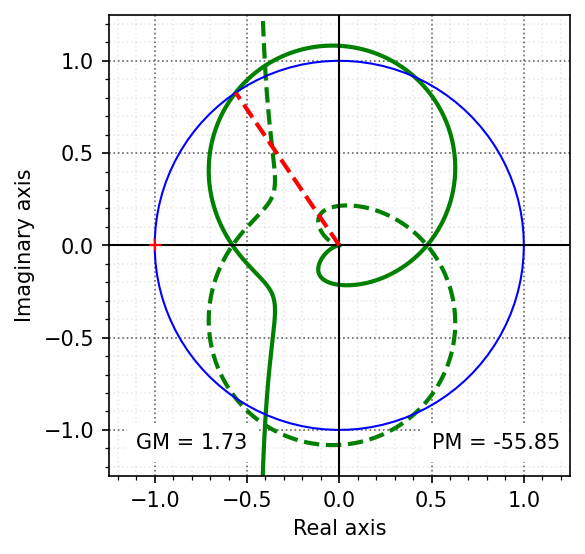

Phase Margin = -55.85


In [138]:
#L(s) =  \frac{0.3( s^2 - 0.075 s + 0.95)}{s(s+1)(s^2+0.025s+0.9)}
w = np.hstack((0,np.logspace(-3,3,50000)))
G = 0.38*ct.tf([1],[1, 1, 0])*ct.tf([1,-.075,.95],[1,.025,.9]) 
display(cm.show_tf_latex(G,'G'))

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(G,w,indent_direction='right',indent_points=100)
ct.nyquist_plot(resp,color='g',linewidth=2,ax=ax)

plt.plot(np.cos(an), np.sin(an),'b-',lw=1)
plt.plot(-1,0,'r+',ms=6,zorder=20)
ax.set_aspect('equal')
plt.xlim([-1.25,1.25])
plt.ylim([-1.25,1.25])
bm.nicegrid(ax,-1)

gm, pm, wcg, wcp =  ct.margin(G)
plt.plot([0,-np.cos(pm/r2d)],[0,-np.sin(pm/r2d)],'r--')
Gf = G(complex(0,1)*w)
S = 1/(1+Gf)
dist_from_cp = 1/np.max(np.abs(S))
plt.plot(-1+dist_from_cp*np.cos(an), dist_from_cp*np.sin(an),'r--',lw=1)

ax.text(.5,-1.1,"PM = {:3.2f}".format(pm),backgroundcolor = 'w', color = 'k')
ax.text(-1.1,-1.1,"GM = {:3.2f}".format(gm),backgroundcolor = 'w', color = 'k')

plt.savefig("./figs/L19_GM_PM_2.pdf", dpi=600)
plt.show()

print("Phase Margin = {:3.2f}".format(pm))


## More Examples


Latex version of G: G(s) = \dfrac{3000.00s - 300.00}{s^4 + 17.00s^3 + 42.00s^2 - 260.00s + 200.00}
Number of unstable poles of G: 1

Found break-in/out at K =  0.000
At possible locations s = -10.000

Found break-in/out at K =  0.008
At possible locations s =  1.429

Found break-in/out at K =  0.000
At possible locations s = -10.000

Found break-in/out at K =  0.008
At possible locations s =  1.429


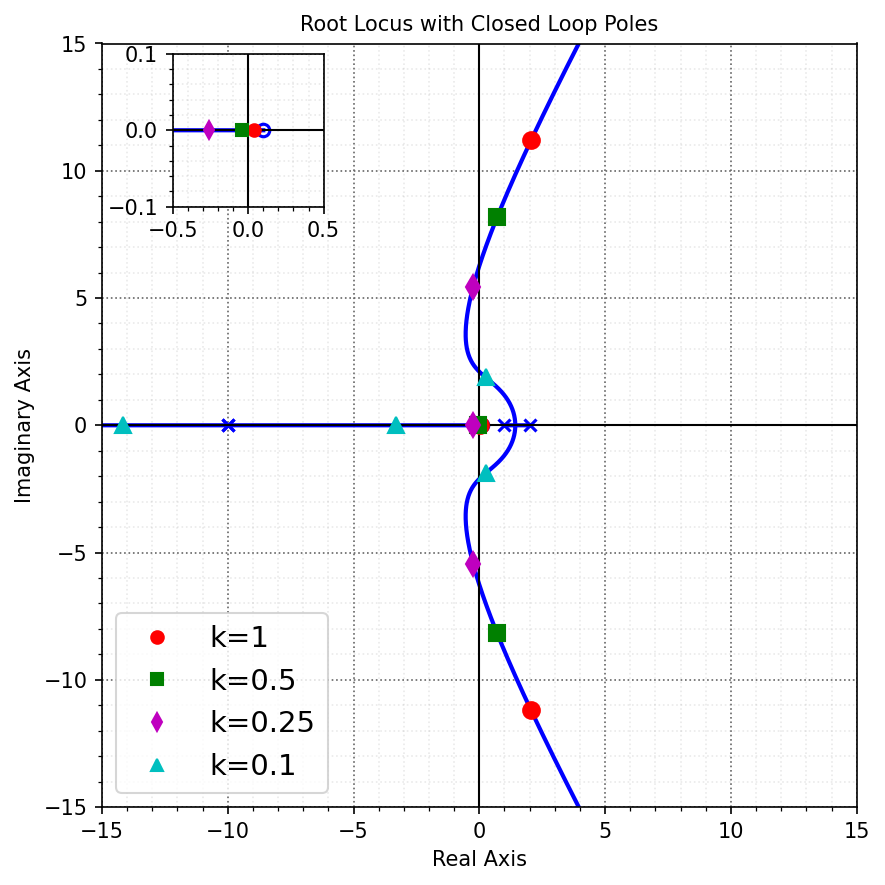

In [139]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

w = np.logspace(-3,3,5000)
G = 3000*ct.tf([1,-0.1],[1,-1])*ct.tf(1,[1,-2])*ct.tf([1],[1,10])**2

G_latex = cm.tf_to_latex(G)
P = np.sum(G.poles().real > 0)
print(f"Latex version of G: {G_latex}")
num_unstable_poles = np.sum(P.real > 0)
print(f"Number of unstable poles of G: {num_unstable_poles}")

# Plot root locus and include closed loop poles for specified gains
fig, ax = plt.subplots(1, figsize=(6, 6), dpi=150)
rl =  ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b',  ax=ax)
ax.set_xlim([-15, 15])
ax.set_ylim([-15, 15])
bm.nicegrid(ax)

# Closed loop poles for gains of 1, 1/2, 1/4, 1/10
gains = [1, 1/2, 1/4, 1/10]
colors = ['r', 'g', 'm', 'c']
markers = ['o', 's', 'd', '^']
for gain, color, marker in zip(gains, colors, markers):
    Gcl = ct.feedback(gain * G, 1)
    poles = Gcl.poles()
    ax.plot(poles.real, poles.imag, marker, color=color, label=f'k={gain}', ms=8)

# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color=colors[0], linestyle='None', marker=markers[0], label=f'k={gains[0]}'),
    Line2D([0], [0], color=colors[1], linestyle='None', marker=markers[1], label=f'k={gains[1]}'),
    Line2D([0], [0], color=colors[2], linestyle='None', marker=markers[2], label=f'k={gains[2]}'),
    Line2D([0], [0], color=colors[3], linestyle='None', marker=markers[3], label=f'k={gains[3]}')
]
ax.legend(handles=custom_lines, loc='lower left', fontsize=MEDIUM_SIZE)
ax.set_title('Root Locus with Closed Loop Poles')
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')

# Add an inset to zoom in on the root locus near the origin
ax_inset = inset_axes(ax, width="20%", height="20%", loc=("upper left"),bbox_to_anchor=(0.08, 0, 1, 1), bbox_transform=ax.transAxes)
rl =  ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b',  ax=ax_inset)
ax_inset.set_xlim([-.5, .5])
ax_inset.set_ylim([-.1, .1])
bm.nicegrid(ax_inset)

# Plot closed loop poles in the inset
for gain, color, marker in zip(gains, colors, markers):
    Gcl = ct.feedback(gain * G, 1)
    poles = Gcl.poles()
    ax_inset.plot(poles.real, poles.imag, marker, color=color, ms=6)

plt.savefig("./figs/L21_13_1.pdf", dpi=300)
plt.show()


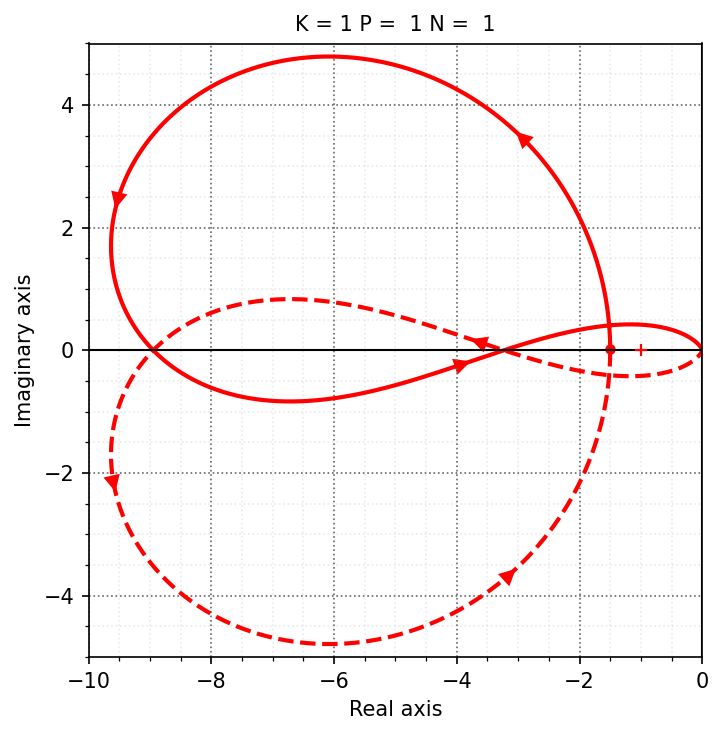

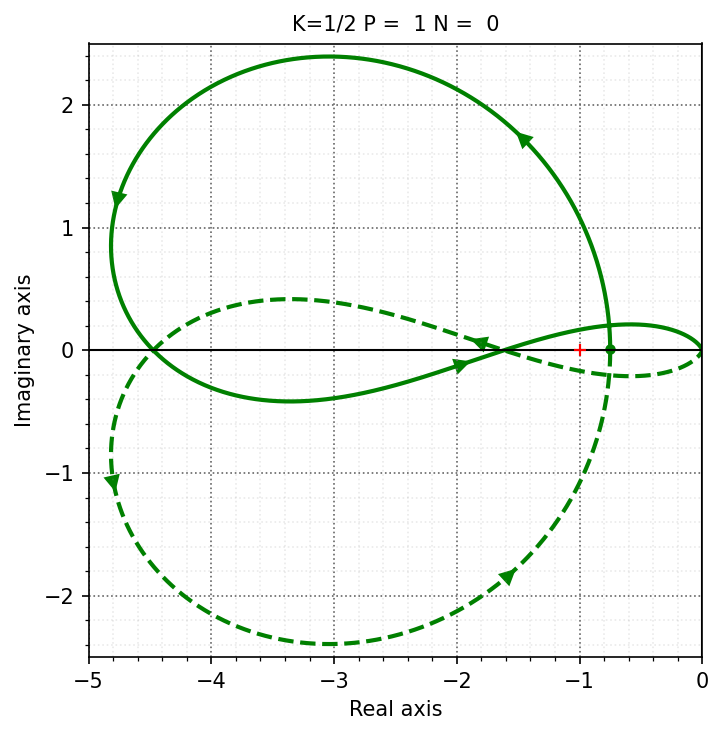

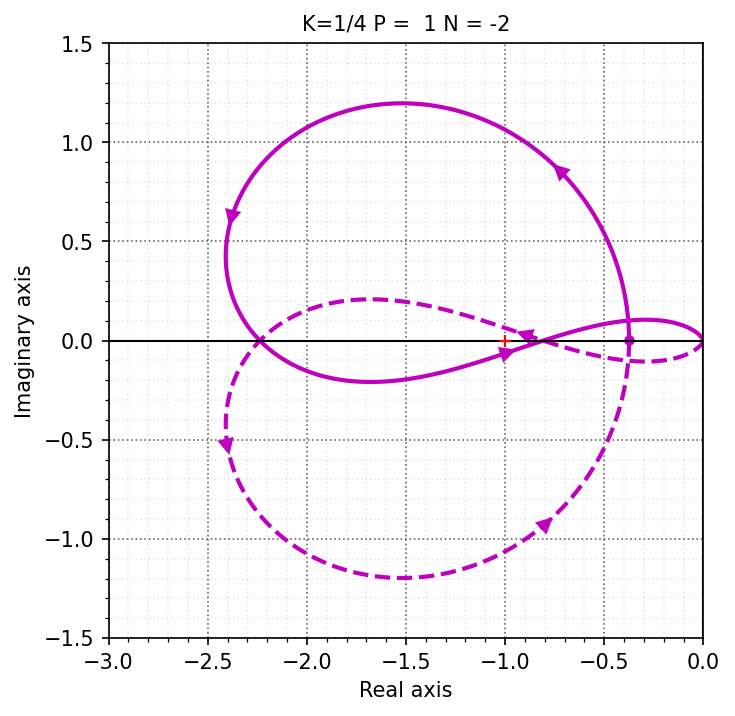

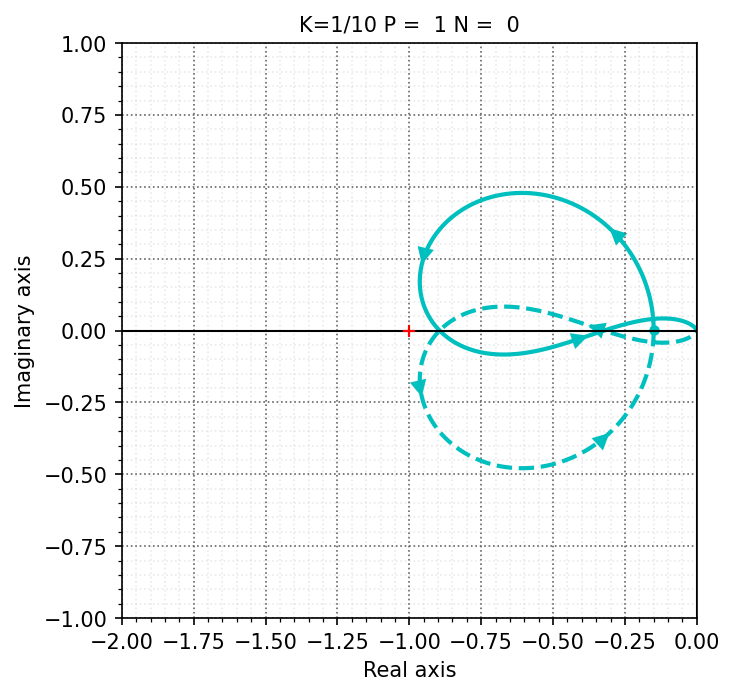

In [140]:
[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)

fig, ax = plt.subplots(1,figsize=(5,5),dpi=150)
resp = ct.nyquist_response(G,w,indent_direction='right',indent_points=100)
ct.nyquist_plot(resp,color='r',linewidth=2,ax=ax)
plt.title(f'K = 1 P = {num_unstable_poles:2d} N = {resp.count:2d}')
plt.plot(-1,0,'r+',ms=6,zorder=20)
ax.set_aspect('equal')
plt.xlim([-10,0])
plt.ylim([-5,5])
bm.nicegrid(ax,-1)
plt.savefig("./figs/L21_13_2.pdf", dpi=600)

fig, ax = plt.subplots(1,figsize=(5,5),dpi=150)
resp = ct.nyquist_response(G/2,w,indent_direction='right',indent_points=100)
ct.nyquist_plot(resp,color='g',linewidth=2,ax=ax)
plt.title(f'K=1/2 P = {num_unstable_poles:2d} N = {resp.count:2d}')
plt.plot(-1,0,'r+',ms=6,zorder=20)
ax.set_aspect('equal')
plt.xlim([-5,0])
plt.ylim([-2.5,2.5])
bm.nicegrid(ax,-1)
plt.savefig("./figs/L21_13_3.pdf", dpi=600)

fig, ax = plt.subplots(1,figsize=(5,5),dpi=150)
resp = ct.nyquist_response(G/4,w,indent_direction='right',indent_points=100)
ct.nyquist_plot(resp,color='m',linewidth=2,ax=ax)
plt.title(f'K=1/4 P = {num_unstable_poles:2d} N = {resp.count:2d}')
plt.plot(-1,0,'r+',ms=6,zorder=20)
ax.set_aspect('equal')
plt.xlim([-3,0])
plt.ylim([-1.5,1.5])
bm.nicegrid(ax,-1)
plt.savefig("./figs/L21_13_4.pdf", dpi=600)

fig, ax = plt.subplots(1,figsize=(5,5),dpi=150)
resp = ct.nyquist_response(G/10,w,indent_direction='right',indent_points=100)
ct.nyquist_plot(resp,color='c',linewidth=2,ax=ax)
plt.title(f'K=1/10 P = {num_unstable_poles:2d} N = {resp.count:2d}')
plt.plot(-1,0,'r+',ms=6,zorder=20)
ax.set_aspect('equal')
plt.xlim([-2,0])
plt.ylim([-1,1])
bm.nicegrid(ax,-1)
plt.savefig("./figs/L21_13_5.pdf", dpi=600)

plt.show()


<TransferFunction>: sys[2219]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s^2 + 0.2 s + 0.01
  ----------------------
  s^5 + 20 s^4 + 100 s^3


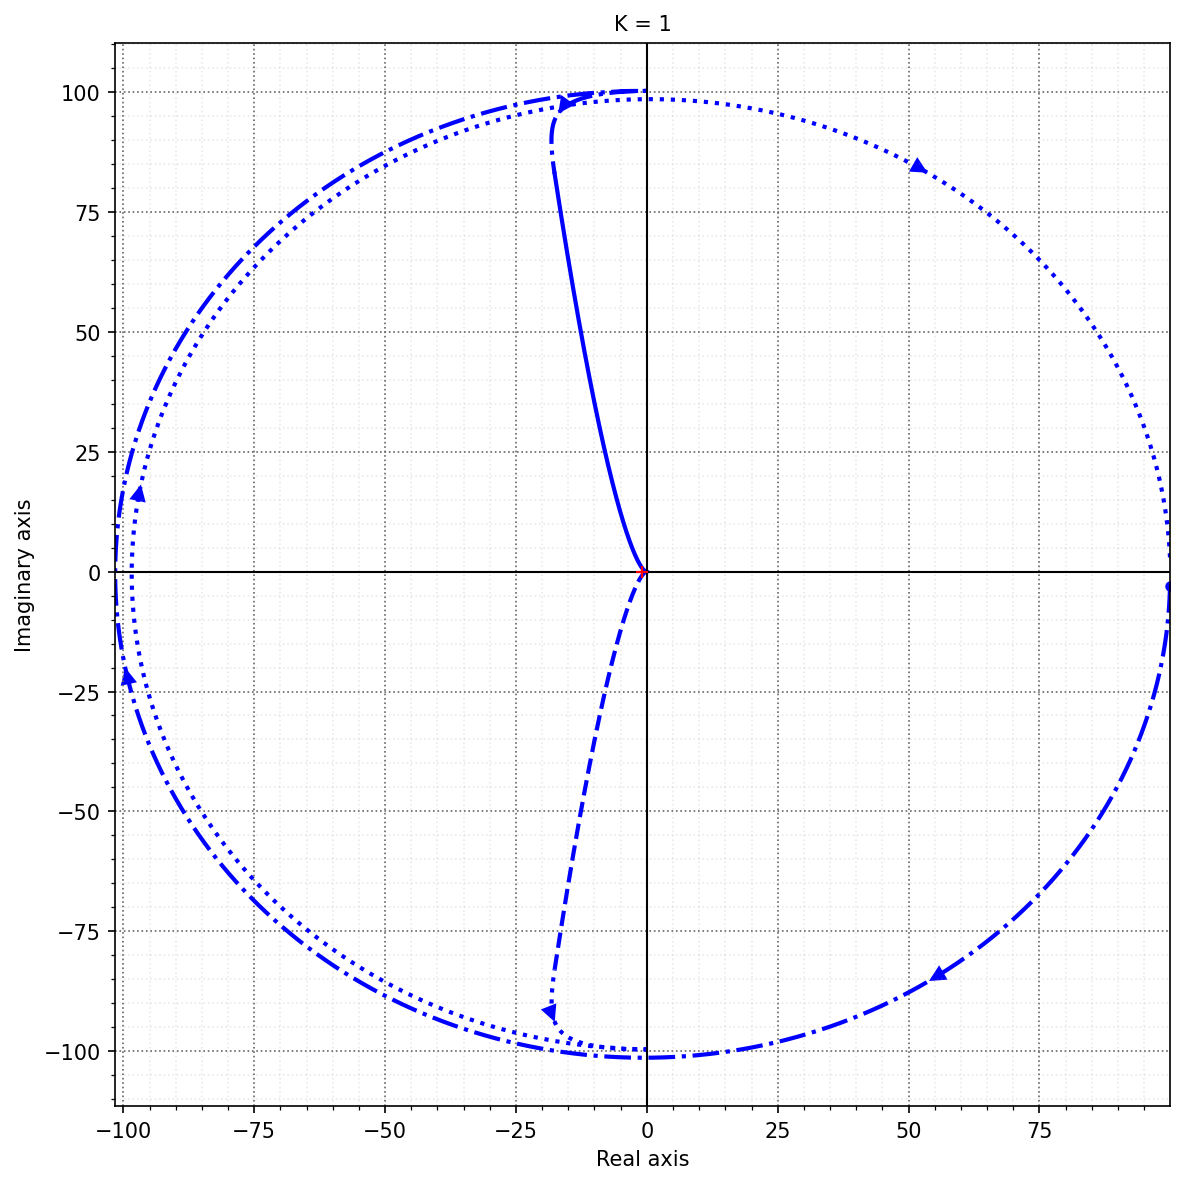

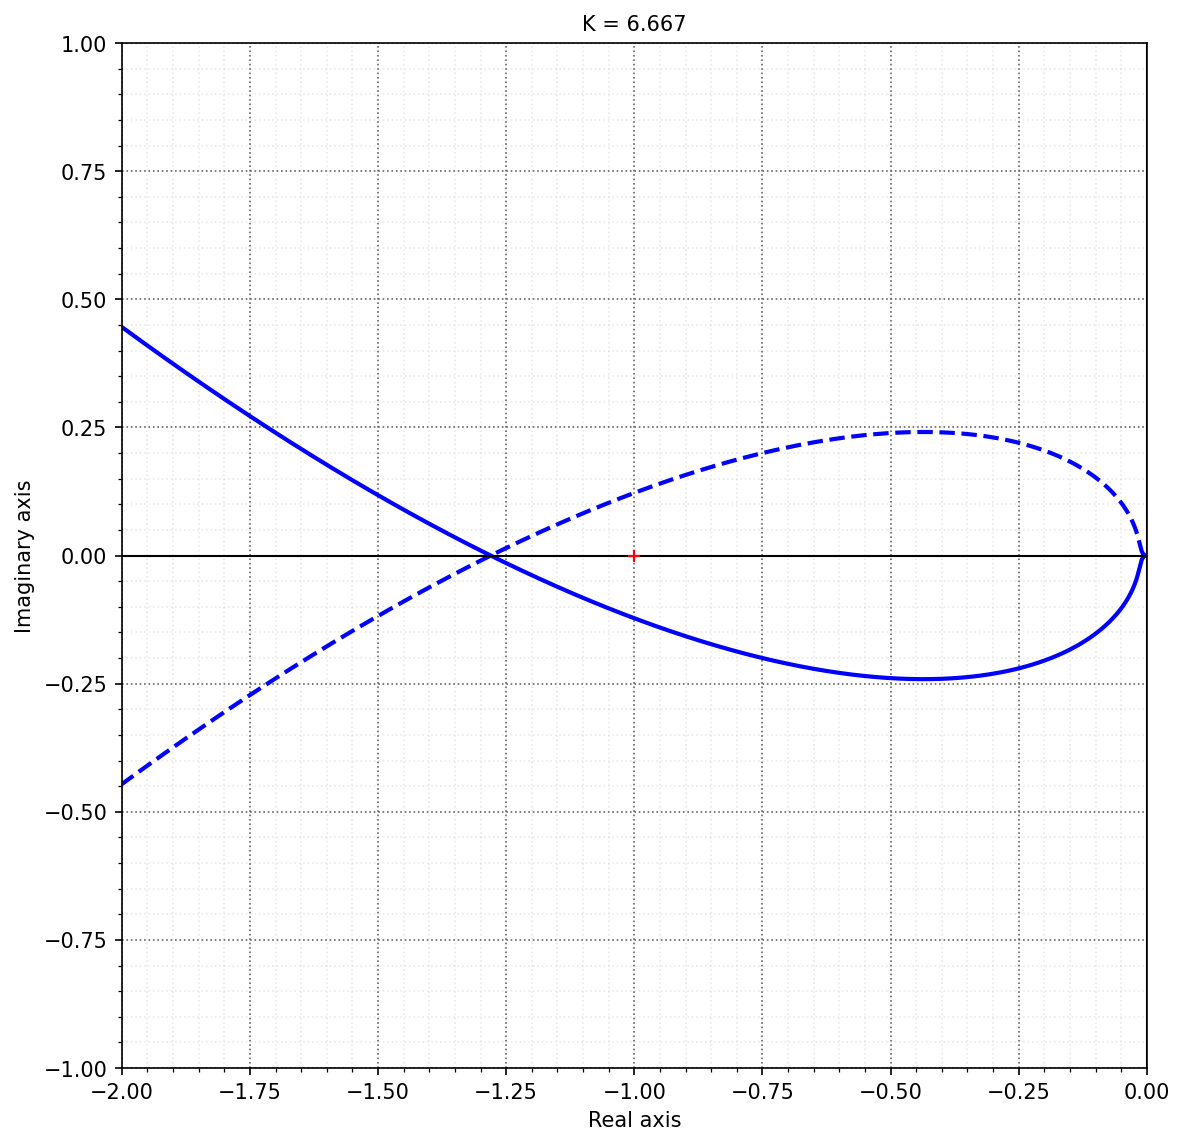

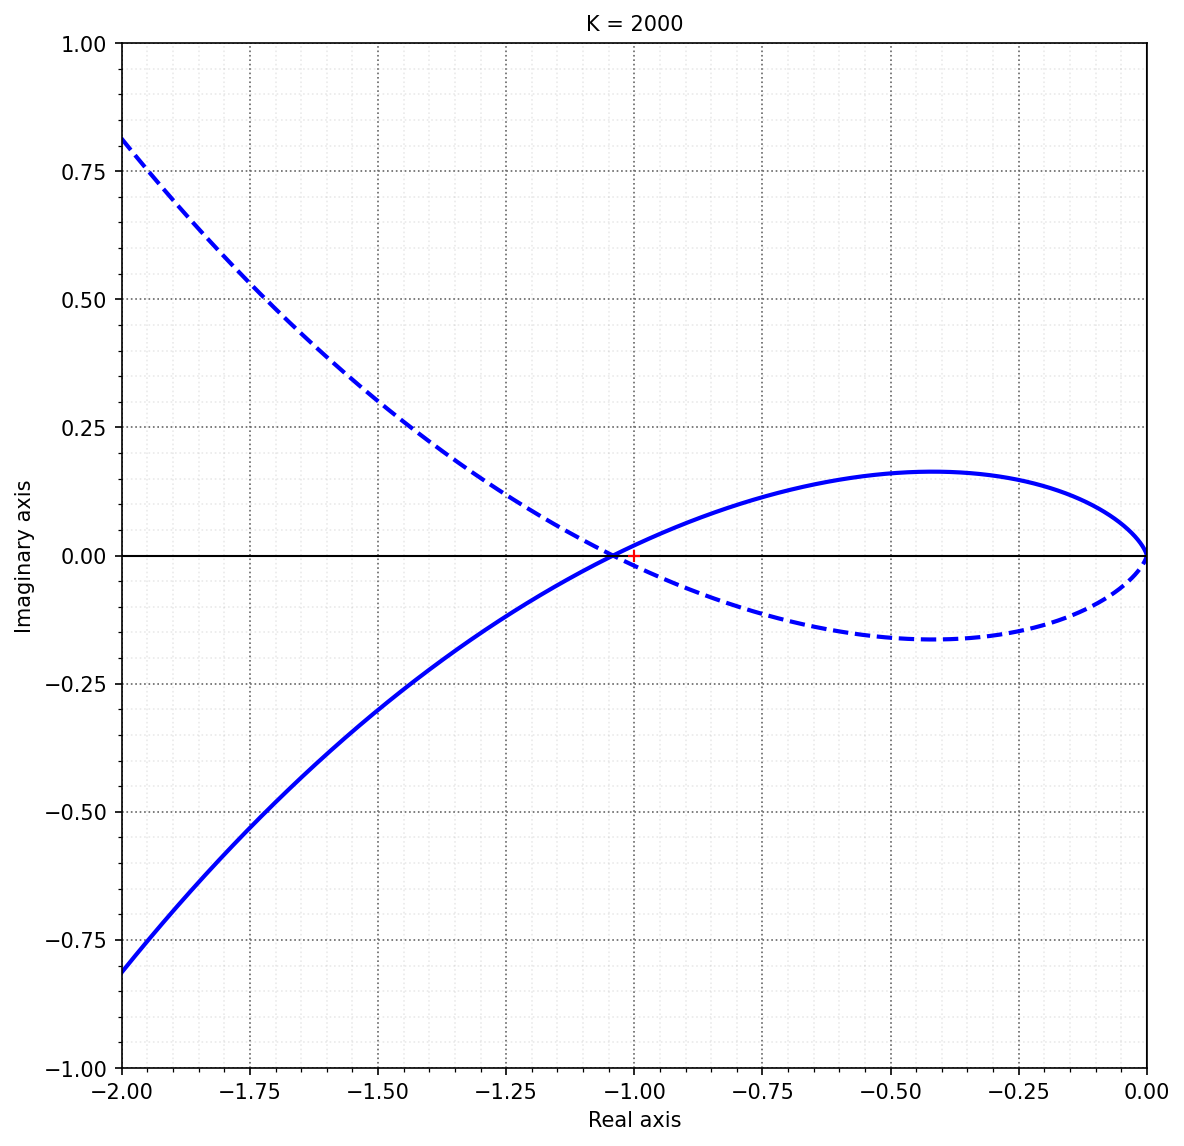

In [141]:
w = np.logspace(-6,6,50000)
G = ct.tf([1],[1,0])**3*ct.tf([1,.1],[1,10])**2 
print(G)
RR = 0.0001

fig, ax1 = plt.subplots(1,figsize=(8, 8),dpi=150)
plt.sca(ax1);
kwargs = {'color':'g'}
resp = ct.nyquist_response(G,w,indent_direction='right',indent_points=100)
ct.nyquist_plot(resp,color='b',linewidth=2,ax=ax1)
plt.title('K = 1')
plt.plot(-1,0,'r+',ms=6,zorder=20)
ax.set_aspect('equal')
#plt.xlim([-2,0])
#plt.ylim([-1,1])
bm.nicegrid(ax1,-1)

fig, ax = plt.subplots(1,figsize=(8, 8),dpi=150)
plt.sca(ax);
resp = ct.nyquist_response(G/.15,w,indent_direction='right',indent_points=100)
ct.nyquist_plot(resp,color='b',linewidth=2,ax=ax)
plt.title('K = 6.667')
plt.plot(-1,0,'r+',ms=6,zorder=20)
ax.set_aspect('equal')
plt.xlim([-2,0])
plt.ylim([-1,1])
bm.nicegrid(ax,-1)

fig, ax = plt.subplots(1,figsize=(8, 8),dpi=150)
resp = ct.nyquist_response(G/.0005,w,indent_direction='right',indent_points=100)
ct.nyquist_plot(resp,color='b',linewidth=2,ax=ax)
plt.title('K = 2000')
plt.plot(-1,0,'r+',ms=6,zorder=20)
ax.set_aspect('equal')
plt.xlim([-2,0])
plt.ylim([-1,1])
bm.nicegrid(ax,-1)